In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
import re
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (classification_report, confusion_matrix,
                             precision_recall_curve, auc, ConfusionMatrixDisplay)
from imblearn.over_sampling import SMOTE
import shap
import lime.lime_text
import warnings
warnings.filterwarnings('ignore')

# Download NLTK resources required for cleaning
nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)
nltk.download('omw-1.4', quiet=True)

# Set global plot style
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['figure.figsize'] = (12, 6)


In [13]:
# UNDERSTANDING DATA
job_postings_df = pd.read_csv("fake_job_postings.csv")

job_postings_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17880 entries, 0 to 17879
Data columns (total 18 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   job_id               17880 non-null  int64 
 1   title                17880 non-null  object
 2   location             17534 non-null  object
 3   department           6333 non-null   object
 4   salary_range         2868 non-null   object
 5   company_profile      14572 non-null  object
 6   description          17879 non-null  object
 7   requirements         15184 non-null  object
 8   benefits             10668 non-null  object
 9   telecommuting        17880 non-null  int64 
 10  has_company_logo     17880 non-null  int64 
 11  has_questions        17880 non-null  int64 
 12  employment_type      14409 non-null  object
 13  required_experience  10830 non-null  object
 14  required_education   9775 non-null   object
 15  industry             12977 non-null  object
 16  func

In [14]:
# Display basic structure and missing value percentages
missing_values_pct = (job_postings_df.isnull().sum() / len(job_postings_df)) * 100
print("=== Missing Values Percentage ===")
print(missing_values_pct[missing_values_pct > 0].sort_values(ascending=False))

# Check target class distribution (Critical for RQ1 & RQ2)
fraud_distribution = job_postings_df['fraudulent'].value_counts(normalize=True)
print("\n=== Target Class Distribution ===")
print(fraud_distribution)

=== Missing Values Percentage ===
salary_range           83.959732
department             64.580537
required_education     45.329978
benefits               40.335570
required_experience    39.429530
function               36.101790
industry               27.421700
employment_type        19.412752
company_profile        18.501119
requirements           15.078300
location                1.935123
description             0.005593
dtype: float64

=== Target Class Distribution ===
fraudulent
0    0.951566
1    0.048434
Name: proportion, dtype: float64


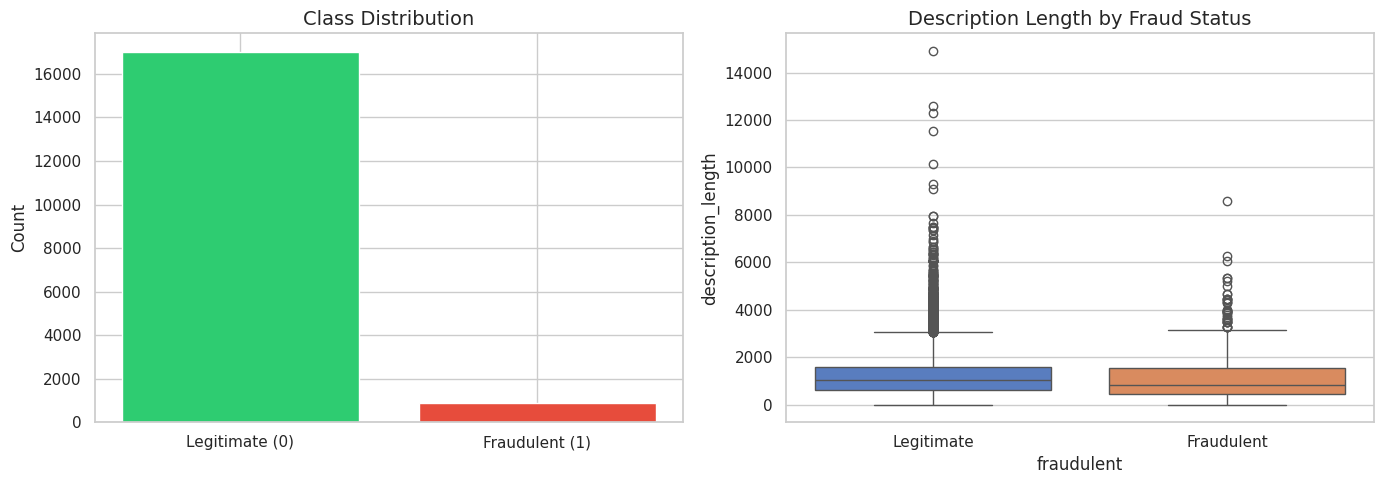

In [15]:
#  EXPLORATORY DATA ANALYSIS (EDA)
# Visualize class imbalance to justify SMOTE usage later
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart of fraudulent vs legitimate counts
fraud_counts = job_postings_df['fraudulent'].value_counts()
axes[0].bar(['Legitimate (0)', 'Fraudulent (1)'], fraud_counts.values, color=['#2ecc71', '#e74c3c'])
axes[0].set_title('Class Distribution', fontsize=14)
axes[0].set_ylabel('Count')

# Box plot of text length by class (Linguistic characteristic analysis for RQ3)
job_postings_df['description_length'] = job_postings_df['description'].astype(str).str.len()
sns.boxplot(data=job_postings_df, x='fraudulent', y='description_length', ax=axes[1], palette="muted")
axes[1].set_title('Description Length by Fraud Status', fontsize=14)
axes[1].set_xticklabels(['Legitimate', 'Fraudulent'])

plt.tight_layout()
plt.show()

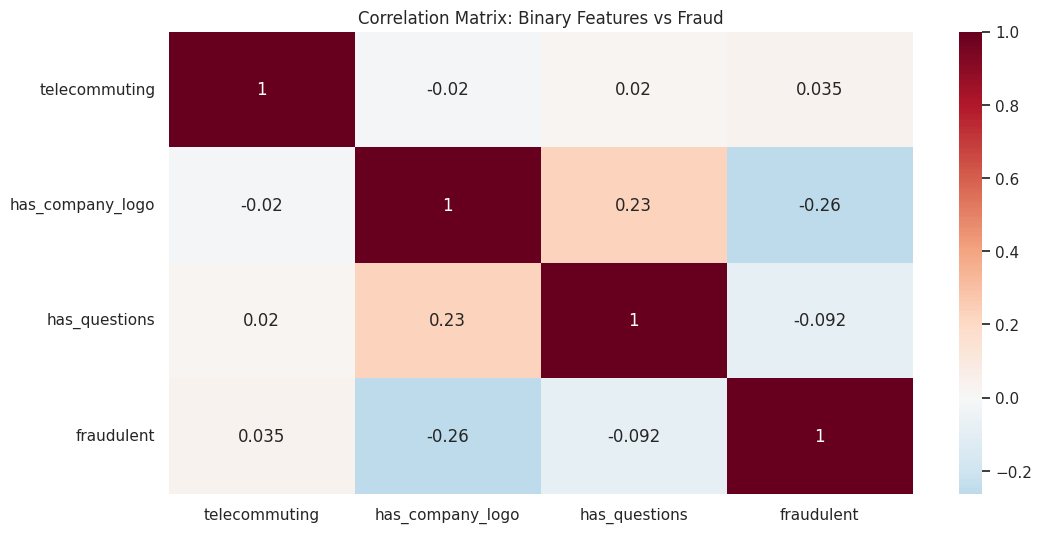

In [16]:
# Correlation heatmap for numerical/binary features
binary_features = ['telecommuting', 'has_company_logo', 'has_questions', 'fraudulent']
sns.heatmap(job_postings_df[binary_features].corr(), annot=True, cmap='RdBu_r', center=0)
plt.title('Correlation Matrix: Binary Features vs Fraud')
plt.show()

In [17]:
# -----------------------------------------------------------------------------
# 2. ADVANCED TEXT CLEANING FUNCTION
# -----------------------------------------------------------------------------
def clean_job_text(text):
    """
    Performs comprehensive NLP preprocessing:
    1. Lowercasing
    2. Removing URLs, HTML tags, and special characters
    3. Removing stopwords
    4. Lemmatization
    """
    if not isinstance(text, str):
        return ""

    # 1. Lowercase
    text = text.lower()

    # 2. Remove URLs and HTML-like tags
    text = re.sub(r'http\S+', '', text)
    text = re.sub(r'<.*?>', '', text)

    # 3. Remove special characters and numbers (keeping only letters and spaces)
    text = re.sub(r'[^a-zA-Z\s]', '', text)

    # 4. Tokenize and remove stopwords
    stop_words = set(stopwords.words('english'))
    tokens = text.split()
    filtered_tokens = [word for word in tokens if word not in stop_words]

    # 5. Lemmatization
    lemmatizer = WordNetLemmatizer()
    lemmatized_tokens = [lemmatizer.lemmatize(word) for word in filtered_tokens]

    return ' '.join(lemmatized_tokens)

In [18]:
# Apply cleaning to key textual columns
text_columns = ['title', 'description', 'requirements', 'benefits', 'company_profile']
for col in text_columns:
    job_postings_df[f'{col}_clean'] = job_postings_df[col].fillna('').apply(clean_job_text)

# Combine all cleaned text into one master feature for TF-IDF
job_postings_df['master_text_feature'] = job_postings_df[[f'{col}_clean' for col in text_columns]].agg(' '.join, axis=1)

# Remove rows where the master text is empty after cleaning
job_postings_df = job_postings_df[job_postings_df['master_text_feature'].str.len() > 0].reset_index(drop=True)
print(f"\nData shape after cleaning empty texts: {job_postings_df.shape}")


Data shape after cleaning empty texts: (17880, 25)


In [19]:
# FEATURE ENGINEERING
# Instead of dropping rows with missing salary/department, we create binary flags.
# Fraudulent posts often lack these details.
job_postings_df['has_salary_info'] = job_postings_df['salary_range'].notna().astype(int)
job_postings_df['has_department'] = job_postings_df['department'].notna().astype(int)
job_postings_df['has_education_req'] = job_postings_df['required_education'].notna().astype(int)
job_postings_df['has_experience_req'] = job_postings_df['required_experience'].notna().astype(int)

# Select final numerical/binary features to combine with TF-IDF later if needed
# For this NLP-focused study, we will primarily rely on the text, but these flags
# can be appended to the TF-IDF matrix for a hybrid model.
numerical_features = ['telecommuting', 'has_company_logo', 'has_questions',
                      'has_salary_info', 'has_department', 'has_education_req', 'has_experience_req']

In [20]:
# FEATURE EXTRACTION (TF-IDF)
tfidf_vectorizer = TfidfVectorizer(
    max_features=15000,      # Increased slightly due to better cleaning
    ngram_range=(1, 2),      # Unigrams and Bigrams
    min_df=3,                # Ignore very rare words
    max_df=0.90,             # Ignore very common words
    sublinear_tf=True        # Log normalization
)

tfidf_matrix = tfidf_vectorizer.fit_transform(job_postings_df['master_text_feature'])
feature_names_list = tfidf_vectorizer.get_feature_names_out()

In [21]:
# Prepare target
y_labels = job_postings_df['fraudulent']

# Split data (Stratified to maintain imbalance ratio in test set)
X_train_tfidf, X_test_tfidf, y_train, y_test = train_test_split(
    tfidf_matrix, y_labels, test_size=0.2, random_state=42, stratify=y_labels
)

In [22]:
# HANDLING CLASS IMBALANCE (SMOTE)
# Apply SMOTE ONLY to training data
smote_sampler = SMOTE(random_state=42, sampling_strategy=0.5) # Oversample minority to 50% of majority
X_train_resampled, y_train_resampled = smote_sampler.fit_resample(X_train_tfidf, y_train)

print(f"\nTraining set before SMOTE: {y_train.value_counts().to_dict()}")
print(f"Training set after SMOTE:  {pd.Series(y_train_resampled).value_counts().to_dict()}")


Training set before SMOTE: {0: 13611, 1: 693}
Training set after SMOTE:  {0: 13611, 1: 6805}


In [23]:
# MODEL DEVELOPMENT & EVALUATION
models_dict = {
    "Naive_Bayes": MultinomialNB(),
    "Linear_SVM": LinearSVC(class_weight='balanced', max_iter=5000),
    "Random_Forest": RandomForestClassifier(n_estimators=150, class_weight='balanced', random_state=42, n_jobs=-1),
    "XGBoost_GB": GradientBoostingClassifier(n_estimators=150, max_depth=4, random_state=42)
}

evaluation_metrics = {}

for name, model in models_dict.items():
    print(f"\n--- Training {name} ---")
    model.fit(X_train_resampled, y_train_resampled)

    # Predictions
    y_pred = model.predict(X_test_tfidf)

    # For PR Curve, we need probabilities or decision scores
    if hasattr(model, 'predict_proba'):
        y_scores = model.predict_proba(X_test_tfidf)[:, 1]
    else:
        # For SVM, use decision function
        y_scores = model.decision_function(X_test_tfidf)
        # Normalize scores to [0, 1] for consistency in plotting
        y_scores = (y_scores - y_scores.min()) / (y_scores.max() - y_scores.min())

    # Metrics
    report = classification_report(y_test, y_pred, target_names=['Legit', 'Fraud'])
    pr_precision, pr_recall, _ = precision_recall_curve(y_test, y_scores)
    pr_auc = auc(pr_recall, pr_precision)

    evaluation_metrics[name] = {'pr_auc': pr_auc, 'model': model, 'scores': y_scores, 'preds': y_pred}

    print(f"PR-AUC: {pr_auc:.4f}")
    print(report)


--- Training Naive_Bayes ---
PR-AUC: 0.8652
              precision    recall  f1-score   support

       Legit       1.00      0.95      0.97      3403
       Fraud       0.51      0.91      0.65       173

    accuracy                           0.95      3576
   macro avg       0.75      0.93      0.81      3576
weighted avg       0.97      0.95      0.96      3576


--- Training Linear_SVM ---
PR-AUC: 0.9354
              precision    recall  f1-score   support

       Legit       0.99      1.00      0.99      3403
       Fraud       0.95      0.83      0.88       173

    accuracy                           0.99      3576
   macro avg       0.97      0.91      0.94      3576
weighted avg       0.99      0.99      0.99      3576


--- Training Random_Forest ---
PR-AUC: 0.9231
              precision    recall  f1-score   support

       Legit       0.98      1.00      0.99      3403
       Fraud       1.00      0.66      0.79       173

    accuracy                           0.98   

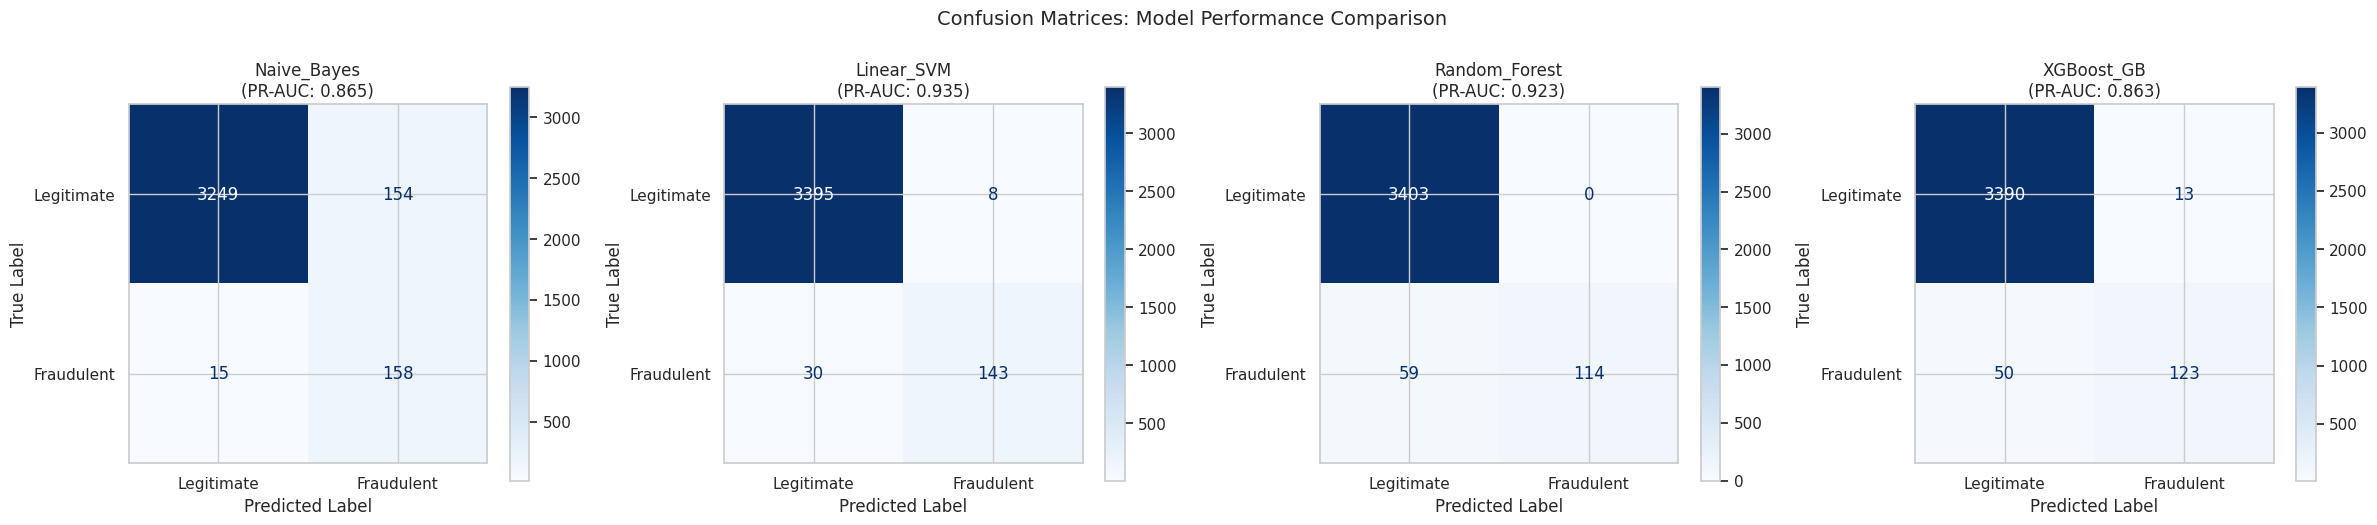

In [29]:
num_models = len(evaluation_metrics)
fig, axes = plt.subplots(1, num_models, figsize=(6 * num_models, 5))

# Handle case where there is only one model (axes won't be an array)
if num_models == 1:
    axes = [axes]

for ax, (name, metrics) in zip(axes, evaluation_metrics.items()):
    # Retrieve predictions from our stored metrics
    y_pred = metrics['preds']

    # Generate Confusion Matrix Display
    cm_display = ConfusionMatrixDisplay.from_predictions(
        y_test,
        y_pred,
        ax=ax,
        cmap='Blues',
        display_labels=['Legitimate', 'Fraudulent'],
        values_format='d' # Show raw counts
    )

    # Customize titles and labels for academic clarity
    ax.set_title(f'{name}\n(PR-AUC: {metrics["pr_auc"]:.3f})', fontsize=12)
    ax.set_xlabel('Predicted Label')
    ax.set_ylabel('True Label')

plt.suptitle('Confusion Matrices: Model Performance Comparison', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

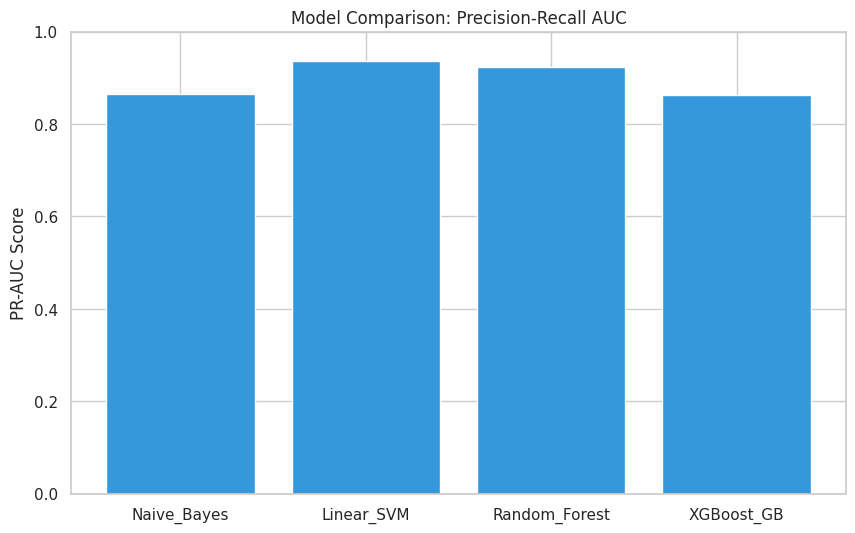

In [24]:
# Visualize Comparison
pr_auc_scores = {k: v['pr_auc'] for k, v in evaluation_metrics.items()}
plt.figure(figsize=(10, 6))
plt.bar(pr_auc_scores.keys(), pr_auc_scores.values(), color='#3498db')
plt.title('Model Comparison: Precision-Recall AUC')
plt.ylabel('PR-AUC Score')
plt.ylim(0, 1)
plt.show()


🔍 Using Best Model for XAI: Linear_SVM


  0%|          | 0/30 [00:00<?, ?it/s]

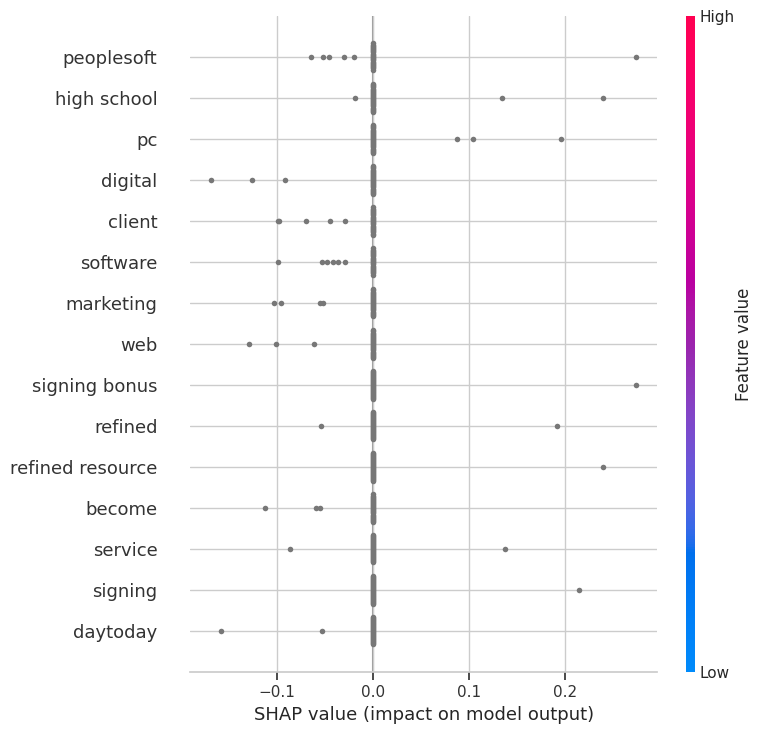

In [25]:
# EXPLAINABLE AI (XAI) - SHAP & LIME
# Select best model based on PR-AUC
best_model_name = max(evaluation_metrics, key=lambda k: evaluation_metrics[k]['pr_auc'])
best_model = evaluation_metrics[best_model_name]['model']
print(f"\n🔍 Using Best Model for XAI: {best_model_name}")

# Sample a small subset for XAI to avoid memory/time issues
sample_size = 30
sample_indices = np.random.choice(X_test_tfidf.shape[0], sample_size, replace=False)
X_test_sample = X_test_tfidf[sample_indices]
y_test_sample = y_test.iloc[sample_indices]
original_texts_sample = job_postings_df['master_text_feature'].iloc[y_test.index[sample_indices]].values

# --- SHAP Analysis ---
# Use TreeExplainer if it's a tree-based model, otherwise KernelExplainer
if 'Forest' in best_model_name or 'Boost' in best_model_name:
    shap_explainer = shap.TreeExplainer(best_model)
else:
    # For NB or SVM, use KernelExplainer (slower)
    shap_explainer = shap.KernelExplainer(best_model.predict_proba if hasattr(best_model, 'predict_proba') else best_model.decision_function, X_test_sample[:10])

shap_values = shap_explainer.shap_values(X_test_sample)

# Plot Summary (Global Importance)
# Note: For multi-class or binary, shap_values might be a list. We take the positive class [1]
if isinstance(shap_values, list):
    shap_vals_positive = shap_values[1]
else:
    shap_vals_positive = shap_values

shap.summary_plot(shap_vals_positive, X_test_sample, feature_names=feature_names_list, max_display=15)

Explaining Job ID: 14001
True Label: Fraudulent (1)

✅ LIME Explanation Generated Successfully.


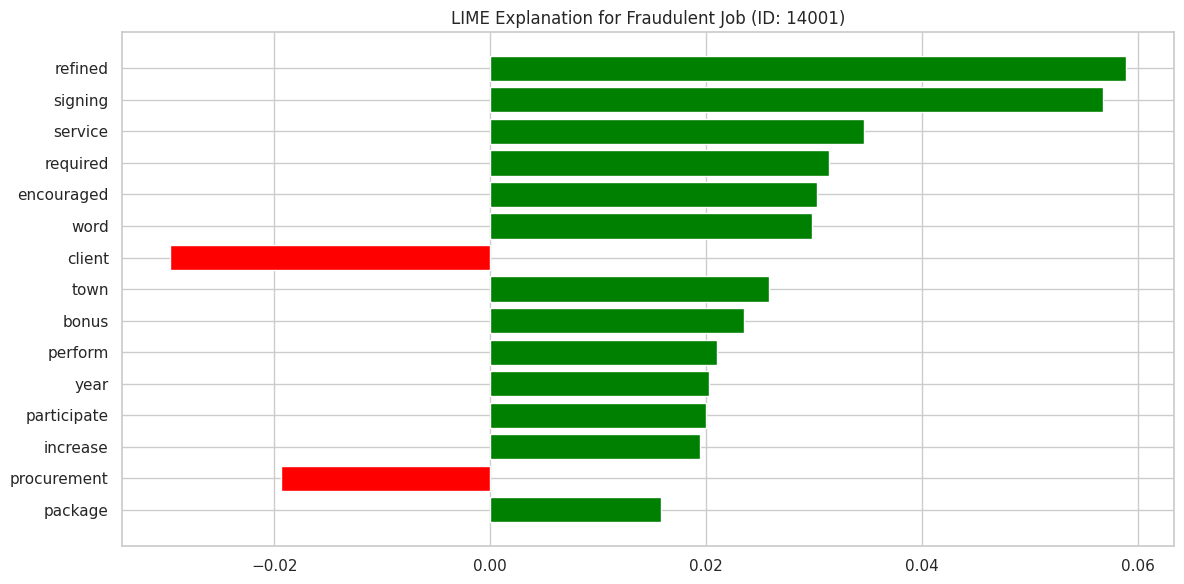


Top Features Contributing to 'Fraud' Classification:
- refined: 0.0589
- signing: 0.0568
- service: 0.0346
- required: 0.0314
- encouraged: 0.0303
- word: 0.0298
- client: -0.0297
- town: 0.0258
- bonus: 0.0235
- perform: 0.0210
- year: 0.0203
- participate: 0.0200
- increase: 0.0195
- procurement: -0.0194
- package: 0.0159


In [28]:
# LIME ANALYSIS (Local Explanation)
lime_explainer = lime.lime_text.LimeTextExplainer(class_names=['Legitimate', 'Fraudulent'])

# Define a robust prediction function that handles 2D array requirements
def predict_proba_for_lime(texts):
    """
    Wrapper to ensure models receive 2D sparse matrices and return probabilities.
    """
    # Transform the list of texts using the SAME vectorizer used in training
    texts_transformed = tfidf_vectorizer.transform(texts)

    if hasattr(best_model, 'predict_proba'):
        return best_model.predict_proba(texts_transformed)
    else:
        # For SVM/Linear models without predict_proba
        scores = best_model.decision_function(texts_transformed)
        # Convert decision scores to probabilities using sigmoid-like normalization
        probs = 1 / (1 + np.exp(-scores))
        # Stack to create [prob_legit, prob_fraud] format
        return np.column_stack([1 - probs, probs])

# Find a fraudulent example in the sample to explain
fraud_indices_in_sample = np.where(y_test_sample.values == 1)[0]

if len(fraud_indices_in_sample) > 0:
    idx = fraud_indices_in_sample[0]
    text_to_explain = original_texts_sample[idx]

    print(f"Explaining Job ID: {job_postings_df.iloc[y_test.index[sample_indices][idx]]['job_id']}")
    print(f"True Label: Fraudulent (1)")

    try:
        # Explain instance
        exp = lime_explainer.explain_instance(
            text_to_explain,
            predict_proba_for_lime,
            num_features=15,
            num_samples=500
        )

        print("\n✅ LIME Explanation Generated Successfully.")

        # 1. Display as a Matplotlib Figure (Best for Colab/Reports)
        fig = exp.as_pyplot_figure(label=1) # label=1 is Fraudulent
        plt.title(f"LIME Explanation for Fraudulent Job (ID: {job_postings_df.iloc[y_test.index[sample_indices][idx]]['job_id']})")
        plt.tight_layout()
        plt.show()

        # 2. Print Text-Based Explanation (Backup for clarity)
        print("\nTop Features Contributing to 'Fraud' Classification:")
        for word, weight in exp.as_list(label=1):
            print(f"- {word}: {weight:.4f}")

    except Exception as e:
        print(f"Error during LIME explanation: {e}")
else:
    print("⚠️ No fraudulent samples found in the small XAI subset.")
    print("Tip: Increase 'sample_size' in the previous step or change random_state to find a fraud case.")